# Propagation of the error and flags

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS
from src.sanity_checks import *
from src.utils import get_flag_cols, normalize_flags

path_save_fig = DATA_FIGURE / "error_propagation"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# 200 reports
# fn_preprocess_reports = "dropped_preproc_text_sel_gaps_merged_df_with_clean_text_all-all_reports_with_pdf_status_020726_with_clean_text_v090726"
fn_data = "post_processed_0-778_llm_response_preproc_text_sel_gaps_combined_v300626_v060726_2016-2025_meta-llama_llama-4-scout-17b-16e-instruct_v060726_v080726_geo"
# fn_data_filtered = "filter_post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v170626_geo"
fn_data_labelled = "post_processed_labelled_reports_all_v09072026_v090726_geo"
cols = [
    "appealCode",
    "reportDate",
    "impactSubtype",
    "impactValue",
    "impactValueMin",
    "impactValueMax",
    "impactValuePrecision",
    "impactUnit",
    "valueAnnotation",
    "location",
    "locationAnnotation",
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards",
    'startYear',
    'startMonth',
    'startDay',
    'endYear',
    'endMonth',
    'endDay'
]
data_labelled = gpd.read_file(os.path.join(DATA_OUT_PROC, fn_data_labelled+'.gpkg'), ignore_geometry=True)
# data = gpd.read_parquet(os.path.join(DATA_OUT_PROC, fn_data+'.parquet'))
data = pd.read_csv(os.path.join(DATA_OUT_PROC, fn_data+'.csv'))
# data_filtered = gpd.read_file(os.path.join(DATA_OUT_PROC, fn_data_filtered+'.gpkg'), ignore_geometry=True)
# data_prepoc = pd.read_csv(os.path.join(DATA_IN_JSONS, fn_preprocess_reports+'.csv'), index_col=0)

In [4]:
data_labelled = format_output(data_labelled)
# data_filtered_target = format_output(data_filtered)
#data_preprocessed = format_output(data_prepoc)

## Preprocess flags

In [ ]:
#data_prepoc[["extraction_error"]].value_counts(normalize=False, dropna=False)


NameError: name 'data_prepoc' is not defined

In [ ]:
data_prepoc.loc[data_prepoc["extraction_error"].notnull(), "processing_error"] = (
    "download or extraction error"
)

In [ ]:
data_prepoc[["processing_error"]].value_counts(normalize=False, dropna=False)

processing_error            
invalid appealType              12249
no natural hazard                3020
no impact text                   2027
missing origType                 1917
not in English                     55
download or extraction error       33
Name: count, dtype: int64

<Axes: ylabel='processing_error'>

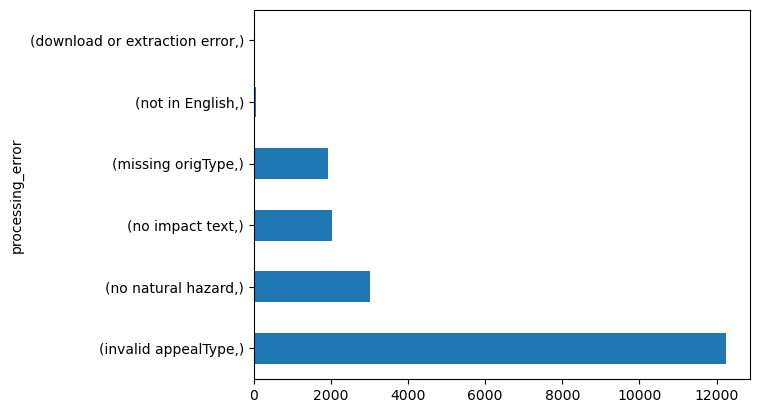

In [40]:
data_prepoc[["processing_error"]].value_counts(normalize=False, dropna=False).plot(kind="barh")


## Normalize flags

In [6]:
flags_cols = get_flag_cols(data)
data[flags_cols] = data[flags_cols].map(normalize_flags)
flags_cols_lab = get_flag_cols(data_labelled)
data_labelled[flags_cols_lab] = data_labelled[flags_cols_lab].map(normalize_flags)

In [7]:
flags_cols

['valid_errors_impactValue',
 'valid_errors_loc',
 'valid_errors_haz',
 'valid_errors_dates',
 'flag_value_not_in_text',
 'flag_missing_startYear',
 'flag_missing_endYear',
 'flag_missing_startMonth',
 'flag_missing_endMonth',
 'flag_missing_startDay',
 'flag_missing_endDay',
 'flag_startYear_after_endYear',
 'flag_inconsistent_year',
 'flag_inconsistent_month',
 'flag_inconsistent_day',
 'flag_impactSubtype_reclass',
 'flag_unknown_subtype',
 'flag_hazards_reclass',
 'flag_hazards_unknown',
 'flag_remove_number_unit',
 'flag_remove_number_unit_error',
 'flag_SI_unit_standardization',
 'flag_SI_unit_standardization_error',
 'flag_unit_harmonization',
 'flag_non_currency_unit_conversion',
 'flag_non_currency_unit_conversion_error',
 'flag_non-SI_unit_standardization_error',
 'flag_non-SI_unit_standardization',
 'flag_people_unit_normalization',
 'flag_currency_conversion',
 'flag_currency_conversion_error',
 'flag_reclass_subtype_from_unit',
 'flag_impactSubtype_merged',
 'flag_inferred

## Process / harmonize flags

In [8]:
def combine_flags(df, new_flag, source_flags, how="any", warn_missing=True):
    """
    Combine several boolean flags into a new flag.

    Parameters
    ----------
    df : pd.DataFrame
    new_flag : str
        Name of the output flag.
    source_flags : list[str]
        Flags to combine.
    how : {"any", "all"}
        Aggregation method.
    warn_missing : bool
        Whether to warn about missing source flags.
    """
    flags_in = [f for f in source_flags if f in df.columns]

    if warn_missing:
        missing = sorted(set(source_flags) - set(flags_in))
        if missing:
            print(f"Warning: Missing flags for '{new_flag}': {missing}")

    if not flags_in:
        df[new_flag] = False
        return df

    values = df[flags_in].fillna(False).astype(bool)

    if how == "all":
        df[new_flag] = values.all(axis=1)
    elif how == "any":
        df[new_flag] = values.any(axis=1)
    else:
        raise ValueError(f"Unknown aggregation method: {how}")

    return df


def drop_flags(df, flags):
    """Drop flags if they exist."""
    return df.drop(columns=[f for f in flags if f in df.columns])


# ---------------------------------------------------------------------
# Create missing flags
# ---------------------------------------------------------------------

# if "flag_years_missing" not in df.columns:
#    df["flag_years_missing"] = df.apply(flag_years_missing, axis=1)


# ---------------------------------------------------------------------
# Flag combinations
# ---------------------------------------------------------------------

FLAG_GROUPS = {
    "flag_impactSubtype_reclass": (
        [
            "flag_impactSubtype_reclass",
            "flag_reclass_subtype_from_unit",
            "flag_impactSubtype_merged",
        ],
        "any",
    ),
    "flag_years_missing_after_inference": (
        [
            "flag_failed_startYear_inference",
            "flag_years_missing",
        ],
        "all",
    ),
    "flag_remove_unit": (
        [
            "flag_remove_unit",
            "flag_response_unit",
        ],
        "any",
    ),
    "flag_incorrect_unit": (
        [
            "flag_partial_unit",
            "flag_unit_nonstd",
            "flag_percent",
        ],
        "any",
    ),
    "flag_unit_harmonization": (
        [
            "flag_people_unit_normalization",
            "flag_non-SI_unit_standardization",
            "flag_SI_unit_standardization",
            "flag_unit_harmonization",
            "flag_remove_number_unit",
        ],
        "any",
    ),
    "flag_unit_conversion": (
        [
            "flag_currency_conversion",
            "flag_unit_conversion",
            "flag_non_currency_unit_conversion",
        ],
        "any",
    ),
    "flag_unit_harmonization_error": (
        [
            "flag_remove_number_unit_error",
            "flag_SI_unit_standardization_error",
            "flag_non-SI_unit_standardization_error",
        ],
        "any",
    ),
    "flag_country_location_missing": (
        [
            "flag_no_location_no_country",
            "flag_country_location_missing",
        ],
        "any",
    ),
    "flag_unit_conversion_error": (
        [
            "flag_unit_conversion_error",
            "flag_currency_conversion_error",
            "flag_non_currency_unit_conversion_error",
        ],
        "any",
    ),
}

for new_flag, (flags, how) in FLAG_GROUPS.items():
    combine_flags(data, new_flag, flags, how)
    combine_flags(data_labelled, new_flag, flags, how)


# ---------------------------------------------------------------------
# Drop obsolete flags
# ---------------------------------------------------------------------

FLAGS_TO_DROP = [
    "flag_reclass_subtype_from_unit",
    "flag_impactSubtype_merged",
    "flag_percent",
    "flag_partial_unit",
    "flag_unit_nonstd",
    "flag_people_unit_normalization",
    "flag_non-SI_unit_standardization",
    "flag_SI_unit_standardization",
    "flag_remove_number_unit",
    "flag_remove_number_unit_error",
    "flag_SI_unit_standardization_error",
    "flag_non-SI_unit_standardization_error",
    "flag_currency_conversion_error",
    "flag_non_currency_unit_conversion",
    "flag_non_currency_unit_conversion_error",
    "flag_response_unit",
    "flag_years_missing",
    "flag_currency_conversion",
    "flag_no_location_no_country",
]

data = drop_flags(data, FLAGS_TO_DROP)
data_labelled = drop_flags(data_labelled, FLAGS_TO_DROP)

In [9]:
# filter flags
unwanted_flags = [  # flags to filter out (i.e. keep only rows for which these flags are False)
    "flag_remove_cat",
    #"flag_value_no_unit",
    "flag_incorrect_unit",
    #"flag_unit_nonstd",
    #"flag_response_unit",
    "flag_unknown_subtype",
    "flag_all_hazards_unknown",
    "flag_pop_cntry",
    # "flag_value_not_in_text",
    "flag_no_location_no_country",
    "flag_country_location_missing",
    "flag_remove_unit",
    "flag_remove_hazard",
    "flag_years_missing_after_inference",
    #"flag_failed_startYear_inference",
    #"flag_inconsistent_year",
]

data_filtered = data[~data[[flag for flag in unwanted_flags if flag in data.columns]].any(axis=1)]
data_labelled_filtered = data_labelled[~data_labelled[[flag for flag in unwanted_flags if flag in data_labelled.columns]].any(axis=1)]
results_dict = {"pre-filter": data, "post-filter": data_filtered, "post-filter-labelled": data_labelled_filtered, "pre-filter-labelled": data_labelled}

In [10]:
# check count of error and flag cols for both dataframes
for df_name, df in results_dict.items():

    error_cols = [col for col in df.columns if "error" in col]
    flag_cols = [
        col
        for col in df.columns
        if col.startswith("flag_") or col.startswith("valid_")
    ]
    print(f"DataFrame: {df_name}")
    print(f"Number of error columns: {len(error_cols)}")
    print(f"Number of flag columns: {len(flag_cols)}")

DataFrame: pre-filter
Number of error columns: 6
Number of flag columns: 41
DataFrame: post-filter
Number of error columns: 6
Number of flag columns: 41
DataFrame: post-filter-labelled
Number of error columns: 2
Number of flag columns: 36
DataFrame: pre-filter-labelled
Number of error columns: 2
Number of flag columns: 36


## Plots

In [11]:
dict_flag_name_plot = {
    "flag_value_not_in_text" : "Value not in text",
    "flag_percent" : "Unit Percentage",
    "flag_unit_not_in_text" : "Unit not in text",
    "flag_value_no_unit" : "Value without unit",
    "flag_incorrect_unit" : "Incorrect unit",
    "flag_unit_correction" : "Unit corrected",
}

In [12]:
flags_by_type = {
    "Extraction errors": [
        "valid_errors_impactSubtype",
        "valid_errors_impactValue",
        "valid_errors_loc",
        "valid_errors_haz",
        "valid_errors_dates",
    ],
    "Post-processing": [
        "flag_impactSubtype_reclass",
        "flag_unit_harmonization",
        "flag_unit_conversion",
        "flag_hazards_reclass",
        "flag_inferred_startYear",
        # "flag_fail_country_iso",
        # "flag_location_to_country",
        "flag_osm_polygon",
        "flag_nomin_translate",
    ],
    "Post-processing errors": [
        "flag_unit_harmonization_error",
        "flag_unit_conversion_error",
        "flag_failed_startYear_inference",
        "flag_fail_country_iso",
        "flag_nomin_no_result",
        "flag_nomin_sim_below_th",
    ],
    "Warnings": [
        "flag_value_no_unit",
        "flag_hazards_unknown",
        "flag_value_not_in_text",
        "flag_missing_startYear",
        "flag_missing_endYear",
        "flag_missing_startMonth",
        "flag_missing_endMonth",
        "flag_missing_startDay",
        "flag_missing_endDay",
        "flag_startYear_after_endYear",
        "flag_inconsistent_year",
        "flag_inconsistent_month",
        "flag_inconsistent_day",
        "flag_location_to_country",
        # "flag_osm_polygon",
        "flag_no_location",
    ],
    "Error removals": [
        "flag_unknown_subtype",
        "flag_incorrect_unit",
        "flag_all_hazards_unknown",
        "flag_years_missing_after_inference",
        "flag_no_location_no_country",
        "flag_country_location_missing",
        "flag_pop_cntry",
    ],
    "Controlled removals": [
        "flag_remove_cat",
        "flag_remove_unit",
        "flag_remove_hazard",
    ],
}

In [13]:
# check missing flags
plot_flags = [flag for flags in flags_by_type.values() for flag in flags]
missing_flags = [flag for flag in flag_cols if flag not in plot_flags]

In [14]:
missing_flags

[]

In [15]:
# separate between processing/warning flags and flags that remove rows
flags_by_category = {
    "Impact subtype": [
        "valid_errors_impactSubtype",
        "flag_impactSubtype_reclass",
        "flag_reclass_subtype_from_unit",
        "flag_impactSubtype_merged",
        "flag_unknown_subtype",
        "flag_remove_cat",
    ],
    "Impact value & unit": [
        "flag_incorrect_unit",
        "valid_errors_impactValue",
        #"flag_remove_number_unit",
        "flag_unit_harmonization",
        "flag_unit_conversion",
        #"flag_SI_unit_standardization",
        #"flag_non-SI_unit_standardization",
        #"flag_people_unit_normalization",
        #"flag_currency_conversion",
        #"flag_percent",
        #"flag_unit_nonstd",
        "flag_value_no_unit",
        #"flag_partial_unit",
        "flag_value_not_in_text",
        "flag_unit_conversion_error",
        "flag_pop_cntry",
        #"flag_remove_number_unit_error",
        #"flag_SI_unit_standardization_error",
        #"flag_non-SI_unit_standardization_error",
        "flag_unit_harmonization_error",
        #"flag_currency_conversion_error",
        "flag_remove_unit",
        #"flag_response_unit",
    ],
    "Hazards": [
        "valid_errors_haz",
        "flag_hazards_reclass",
        "flag_hazards_unknown",
        "flag_remove_hazard",
        "flag_all_hazards_unknown",
    ],
    "Dates": [
        "valid_errors_dates",
        "flag_missing_startYear",
        "flag_missing_endYear",
        "flag_missing_startMonth",
        "flag_missing_endMonth",
        "flag_missing_startDay",
        "flag_missing_endDay",
        "flag_startYear_after_endYear",
        "flag_inconsistent_year",
        "flag_inconsistent_month",
        "flag_inconsistent_day",
        "flag_inferred_startYear",
        "flag_failed_startYear_inference",
        "flag_years_missing",
        "flag_years_missing_after_inference",
    ],
    "Locations": [
        "valid_errors_loc",
        # "flag_geocoding_country",
        # "flag_geocoding_osm",
        "flag_fail_country_iso",
        "flag_location_to_country",
        "flag_osm_polygon",
        "flag_no_location",
        "flag_nomin_no_result",
        "flag_nomin_sim_below_th",
        "flag_nomin_translate",
        "flag_no_location_no_country",
        "flag_country_location_missing",
    ],
}

In [16]:
# check missing flags
plot_flags = [flag for flags in flags_by_category.values() for flag in flags]
missing_flags = [flag for flag in flag_cols if flag not in plot_flags]

In [17]:
missing_flags

[]

In [18]:
missing_flags

[]

In [19]:
from matplotlib.patches import Patch
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def count_flag(df, flag):
    if flag not in df.columns:
        return 0
    return int(df[flag].fillna(False).astype(bool).sum())


def count_rows_with_any_flag(df, flags):
    existing_flags = [flag for flag in flags if flag in df.columns]
    if not existing_flags:
        return 0
    return int(df[existing_flags].fillna(False).astype(bool).any(axis=1).sum())


def label_color(bg):
    rgb = mcolors.to_rgb(bg)
    luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]

    if luminance > 0.6:
        # Light background → dark text
        return tuple(c * 0.45 for c in rgb)
    else:
        # Dark background → light text
        return tuple(1 - (1 - c) * 0.35 for c in rgb)


def darken(color, factor=0.55):
    """Return a darker shade of a hex color."""
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

In [20]:
from matplotlib.patches import Patch

#PLOT_FONT_FAMILY = "DejaVu Sans"
PLOT_AXIS_LABEL_SIZE = 15
PLOT_TICK_LABEL_SIZE = 13
PLOT_ANNOTATION_SIZE = 12
PLOT_TITLE_SIZE = 17
PLOT_LEGEND_SIZE = 13


def plot_pre_post_counts(
    ax,
    df,
    y,
    labels,
    colors,
    xlabel,
    x_max,
    x_ticks,
    legend=False,
    title="",
    count_label="perc",
    bold_mask=None,
    red_mask=None,
):
    """Plot pre/post-filter horizontal stacked bar plot."""

    ax.figure.set_facecolor("white")
    ax.set_facecolor("white")

    # Bars
    ax.barh(
        y,
        df["kept_count"],
        color=colors,
        edgecolor="#2f2f2f",
        linewidth=0.8,
        zorder=2,
    )

    ax.barh(
        y,
        df["dropped_count"],
        left=df["kept_count"],
        color="#d9d9d9",
        edgecolor="#6f6f6f",
        hatch="///",
        linewidth=0.8,
        zorder=2,
    )

    if df["added_count"].gt(0).any():
        ax.barh(
            y,
            df["added_count"],
            left=df["pre_count"],
            color="white",
            edgecolor="#d62728",
            hatch="...",
            linewidth=1.1,
            zorder=2,
        )

    # Text
    for ypos, row in zip(y, df.itertuples()):
        if count_label == "perc" and hasattr(row, "pre_count_perc") and hasattr(row, "post_count_perc"):
            label = (
                f"post {row.post_count_perc:.1f}% / "
                f"pre {row.pre_count_perc:.1f}%"
            )
        elif count_label == "count":
            label = f"post {row.post_count} / pre {row.pre_count}"
        elif count_label == "both" and hasattr(row, "pre_count_perc") and hasattr(row, "post_count_perc"):
            label = (
                f"post {row.post_count} ({row.post_count_perc:.1f}%) / "
                f"pre {row.pre_count} ({row.pre_count_perc:.1f}%)"
            )
        else:
            label = ""
        ax.annotate(
            label,
            xy=(max(row.pre_count, row.post_count), ypos),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            fontsize=PLOT_ANNOTATION_SIZE,
            fontweight="bold" if getattr(row, "row_type", "") != "flag" else "normal",
            annotation_clip=False,
            clip_on=False,
        )

    # Axis
    ax.set_yticks(y)
    ax.set_yticklabels(
        labels,
        fontsize=PLOT_TICK_LABEL_SIZE,
        #fontfamily=PLOT_FONT_FAMILY,
        fontweight="normal",
    )

    if bold_mask is not None:
        for tick, bold in zip(ax.get_yticklabels(), bold_mask):
            if bold:
                tick.set_fontweight("bold")
                tick.set_fontsize(PLOT_TICK_LABEL_SIZE)

    if red_mask is not None:
        for tick, red in zip(ax.get_yticklabels(), red_mask):
            if red:
                tick.set_color(unwanted_flag_color)
                tick.set_fontweight("bold")

    ax.set_xlim(0, x_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])

    ax.tick_params(axis="x", rotation=35, labelsize=PLOT_TICK_LABEL_SIZE)

    ax.grid(axis="x", linestyle=":", alpha=0.35)

    ax.invert_yaxis()
    ax.set_ylim(len(df) - 0.5, -0.5)
    ax.margins(y=0)

    ax.set_xlabel(xlabel, fontsize=PLOT_AXIS_LABEL_SIZE)
    ax.set_title(title, fontsize=PLOT_TITLE_SIZE, fontweight="bold", pad=10, loc="left")
    if legend:
        handles = [
            Patch(
                facecolor="#888888",
                edgecolor="#2f2f2f",
                label="Final count",
            ),
            Patch(
                facecolor="#d9d9d9",
                edgecolor="#6f6f6f",
                hatch="///",
                label="Dropped from final filter",
            ),
        ]

        if df["added_count"].gt(0).any():
            handles.append(
                Patch(
                    facecolor="white",
                    edgecolor="#d62728",
                    hatch="...",
                    label="Post-filter exceeds pre-filter",
                )
            )

        ax.legend(
            handles=handles,
            frameon=True,
            fontsize=PLOT_LEGEND_SIZE,
            loc="lower right",
        )
    return ax.get_figure()

In [23]:
save = True
count_label = "perc"
savename = "combined_validation_flags_detailed_pre_post_delta"
savename += f"_{count_label}" if count_label is not None else ""
flag_dict = flags_by_type
source_dict = results_dict
pre_df = source_dict["pre-filter"]
post_df = source_dict["post-filter"]
category_colors = {
    "Extraction errors": "#F4D29D",
    "Post-processing": "#EFB784",
    "Post-processing errors": "#E89A73",
    "Warnings": "#DD7E67",
    "Error removals": "#C45454",
    "Controlled removals": "#60798B",
}


type_colors = {
    "Impact subtype": "#bebc9a",
    "Impact value & unit": "#ca6702",
    "Hazards": "#5c4cac",
    "Dates": "#96bb99",
    "Locations": "#457b9d",
}
unwanted_flag_color = "#d62728"
try:
    unwanted_flag_set = set(unwanted_flags)
except NameError:
    unwanted_flag_set = set()


plot_rows = []
category_spans = []
all_flags = []

for category, flags in flag_dict.items():
    existing_flags = [
        flag for flag in flags if flag in pre_df.columns or flag in post_df.columns
    ]
    if not existing_flags:
        continue

    flag_rows = []
    for flag in dict.fromkeys(existing_flags):
        pre_count = count_flag(pre_df, flag)
        post_count = count_flag(post_df, flag)
        flag_rows.append(
            {
                "label": flag,
                "category": category,
                "row_type": "flag",
                "pre_count": pre_count,
                "post_count": post_count,
                "color": category_colors.get(category, "#666666"),
            }
        )
        all_flags.append(flag)

    flag_rows = sorted(flag_rows, key=lambda row: (row["pre_count"], row["label"]))
    start = len(plot_rows)
    plot_rows.extend(flag_rows)

    pre_total = count_rows_with_any_flag(pre_df, existing_flags)
    post_total = count_rows_with_any_flag(post_df, existing_flags)
    plot_rows.append(
        {
            "label": f"{category} total",
            "category": category,
            "row_type": "category_total",
            "pre_count": pre_total,
            "post_count": post_total,
            "color": category_colors.get(category, "#666666"),
        }
    )
    end = len(plot_rows) - 1
    category_spans.append((category, start, end))

unique_all_flags = list(dict.fromkeys(all_flags))
plot_rows.append(
    {
        "label": "All groups total",
        "category": "All groups",
        "row_type": "all_total",
        "pre_count": count_rows_with_any_flag(pre_df, unique_all_flags),
        "post_count": count_rows_with_any_flag(post_df, unique_all_flags),
        "color": "#1f1f1f",
    }
)

plot_df = pd.DataFrame(plot_rows)
plot_df["kept_count"] = plot_df[["pre_count", "post_count"]].min(axis=1)
plot_df["dropped_count"] = (plot_df["pre_count"] - plot_df["post_count"]).clip(lower=0)
plot_df["added_count"] = (plot_df["post_count"] - plot_df["pre_count"]).clip(lower=0)

all_total_counts = plot_df.loc[
    (plot_df["label"] == "All groups total")
    & (plot_df["category"] == "All groups"),
    ["pre_count", "post_count"],
].iloc[0]
plot_df["pre_count_perc"] = np.where(
    all_total_counts["pre_count"] > 0,
    plot_df["pre_count"] / len(pre_df) * 100,
    0,
)
plot_df["post_count_perc"] = np.where(
    all_total_counts["post_count"] > 0,
    plot_df["post_count"] / len(post_df) * 100,
    0,
)

y_positions = np.arange(len(plot_df))
fig_height = max(6, 0.36 * len(plot_df))
max_count = int(plot_df[["pre_count", "post_count"]].max().max()) if len(plot_df) else 0
x_padding = 4 * max(2, int(np.ceil(max_count * 0.06)))
x_max = max_count + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)


summary_rows = []
for category, flags in flags_by_category.items():
    pre_count = count_rows_with_any_flag(pre_df, flags)
    post_count = count_rows_with_any_flag(post_df, flags)
    kept_count = min(pre_count, post_count)
    dropped_count = max(pre_count - post_count, 0)
    added_count = max(post_count - pre_count, 0)
    summary_rows.append(
        {
            "category": category,
            "pre_count": pre_count,
            "post_count": post_count,
            "kept_count": kept_count,
            "dropped_count": dropped_count,
            "added_count": added_count,
        }
    )

category_summary = pd.DataFrame(summary_rows)
category_summary = category_summary.sort_values(
    "pre_count", ascending=True
).reset_index(drop=True)
category_summary["pre_count_perc"] = np.where(
    all_total_counts["pre_count"] > 0,
    category_summary["pre_count"] / len(pre_df) * 100,
    0,
)
category_summary["post_count_perc"] = np.where(
    all_total_counts["post_count"] > 0,
    category_summary["post_count"] / len(post_df) * 100,
    0,
)

y_positions_S= np.arange(len(category_summary))
fig_height_S = max(4.5, 0.55 * len(category_summary))
max_count_S = (
    int(category_summary[["pre_count", "post_count"]].max().max())
    if len(category_summary)
    else 0
)
x_padding_S = max(2, int(np.ceil(max_count_S * 0.06)))
x_max_S = max_count_S + x_padding_S
x_tick_step_S = 500
x_ticks_S = np.arange(0, x_max_S + x_tick_step_S, x_tick_step_S)

combined_x_tick_step = 500
combined_max_count = max(max_count, max_count_S)
combined_x_padding = max(600, int(np.ceil(combined_max_count * 0.28)))
combined_x_max = combined_max_count + combined_x_padding
combined_x_ticks = np.arange(
    0, combined_x_max + combined_x_tick_step, combined_x_tick_step
)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_12716\171236289.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return int(df[flag].fillna(False).astype(bool).sum())
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_12716\171236289.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return int(df[flag].fillna(False).astype(bool).sum())
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_12716\171236289.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects

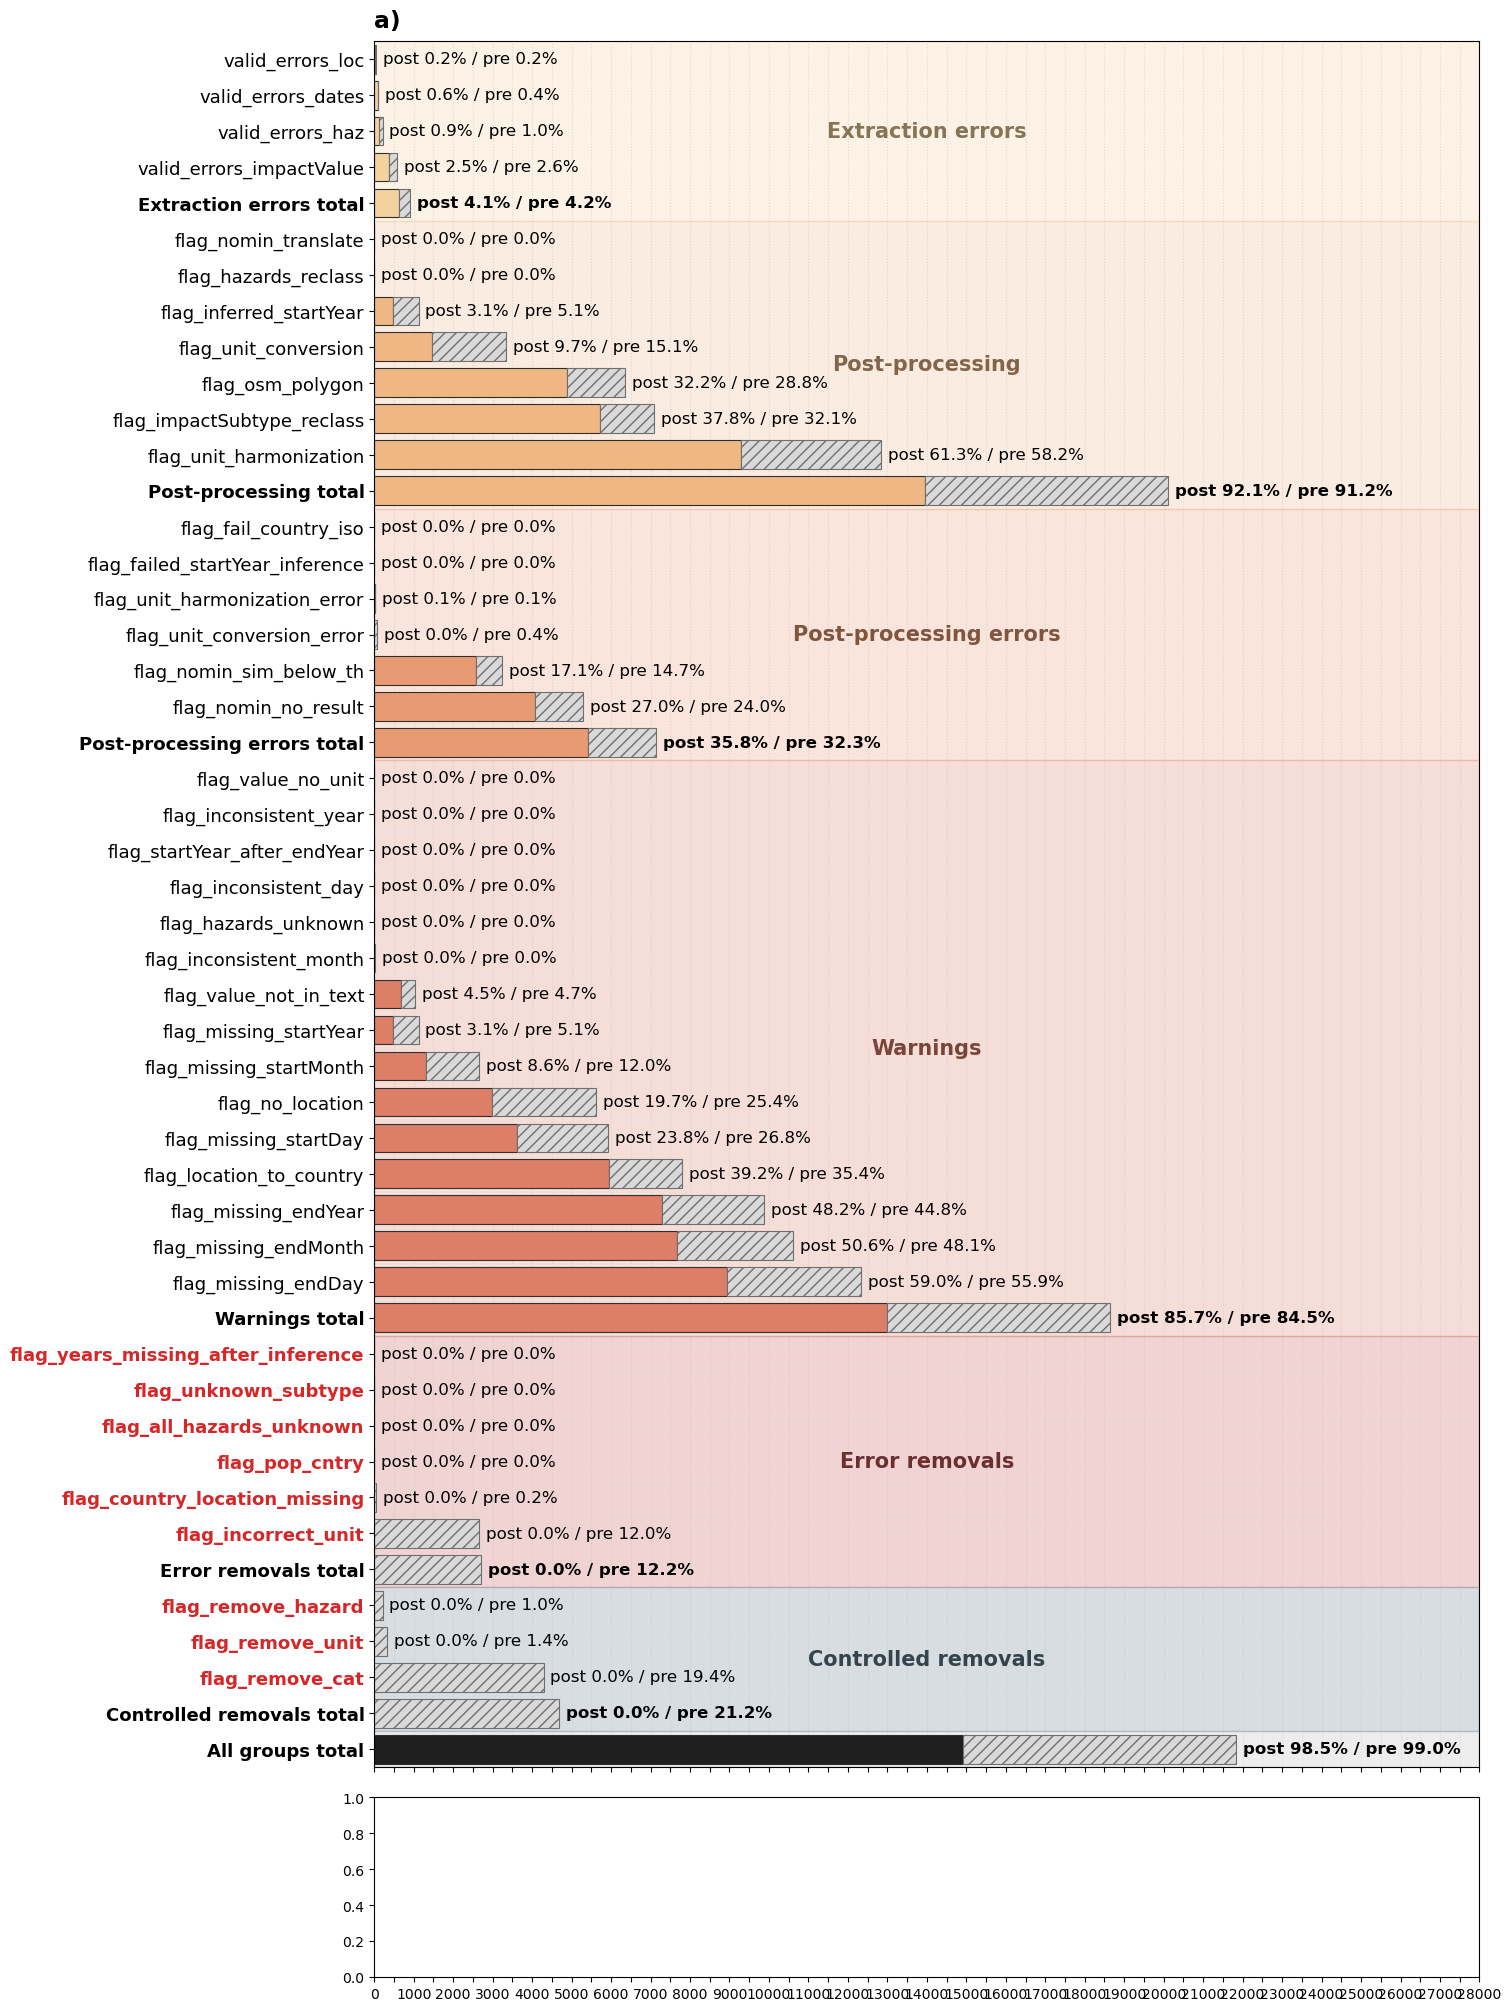

In [24]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 20),
    constrained_layout=True,
    height_ratios=[len(plot_df), len(category_summary)],
    sharex=True,
)
# Background spans
for category, start, end in category_spans:

    bg = category_colors.get(category, "#d9d9d9")

    axes[0].axhspan(
        start - 0.5,
        end + 0.5,
        color=bg,
        alpha=0.25,
        zorder=0,
    )

    axes[0].text(
        0.5,
        start + (end - start) / 2,
        category,
        transform=axes[0].get_yaxis_transform(),
        ha="center",
        va="center",
        fontsize=PLOT_AXIS_LABEL_SIZE,
        fontweight="bold",
        #fontfamily=PLOT_FONT_FAMILY,
        color=darken(bg),
        #bbox={
        #    "facecolor": "white",
        #    "edgecolor": "none",
        #    "boxstyle": "round,pad=0.25",
        #    "alpha": 0.78,
        #},
        clip_on=False,
        zorder=5,
    )

axes[0].axhspan(
    len(plot_df) - 1.5,
    len(plot_df) - 0.5,
    color="#1f1f1f",
    alpha=0.08,
    zorder=0,
)

fig = plot_pre_post_counts(
    axes[0],
    plot_df,
    np.arange(len(plot_df)),
    plot_df["label"],
    plot_df["color"],
    "",
    combined_x_max,
    combined_x_ticks,
    legend=False,
    title="a)",
    count_label=count_label,
    bold_mask=plot_df["row_type"] != "flag",
    red_mask=plot_df["label"].isin(unwanted_flag_set),
)

In [25]:
summary_colors = [
    type_colors.get(cat, "#666666") for cat in category_summary["category"]
]

fig = plot_pre_post_counts(
    axes[1],
    category_summary,
    np.arange(len(category_summary)),
    category_summary["category"],
    summary_colors,
    "Flag count (#)",
    combined_x_max,
    combined_x_ticks,
    count_label=count_label,
    title="b)",
    legend=False,
)

legend_handles = [
    Patch(
        facecolor="#888888",
        edgecolor="#2f2f2f",
        label="Final count",
    ),
    Patch(
        facecolor="#d9d9d9",
        edgecolor="#6f6f6f",
        hatch="///",
        label="Dropped from final filter",
    ),
]
if plot_df["added_count"].gt(0).any() or category_summary["added_count"].gt(0).any():
    legend_handles.append(
        Patch(
            facecolor="white",
            edgecolor="#d62728",
            hatch="...",
            label="Post-filter exceeds pre-filter",
        )
    )

axes[0].legend(
    handles=legend_handles,
    loc=(0.74,1),
    ncol=1,#len(legend_handles),
    frameon=False,
    fontsize=PLOT_LEGEND_SIZE,
)
fig

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(
        os.path.join(path_save_fig, f"{savename}.png"),
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    fig.savefig(
    os.path.join(path_save_fig, f"{savename}.pdf"),
    bbox_inches="tight",
    facecolor="white",
    )

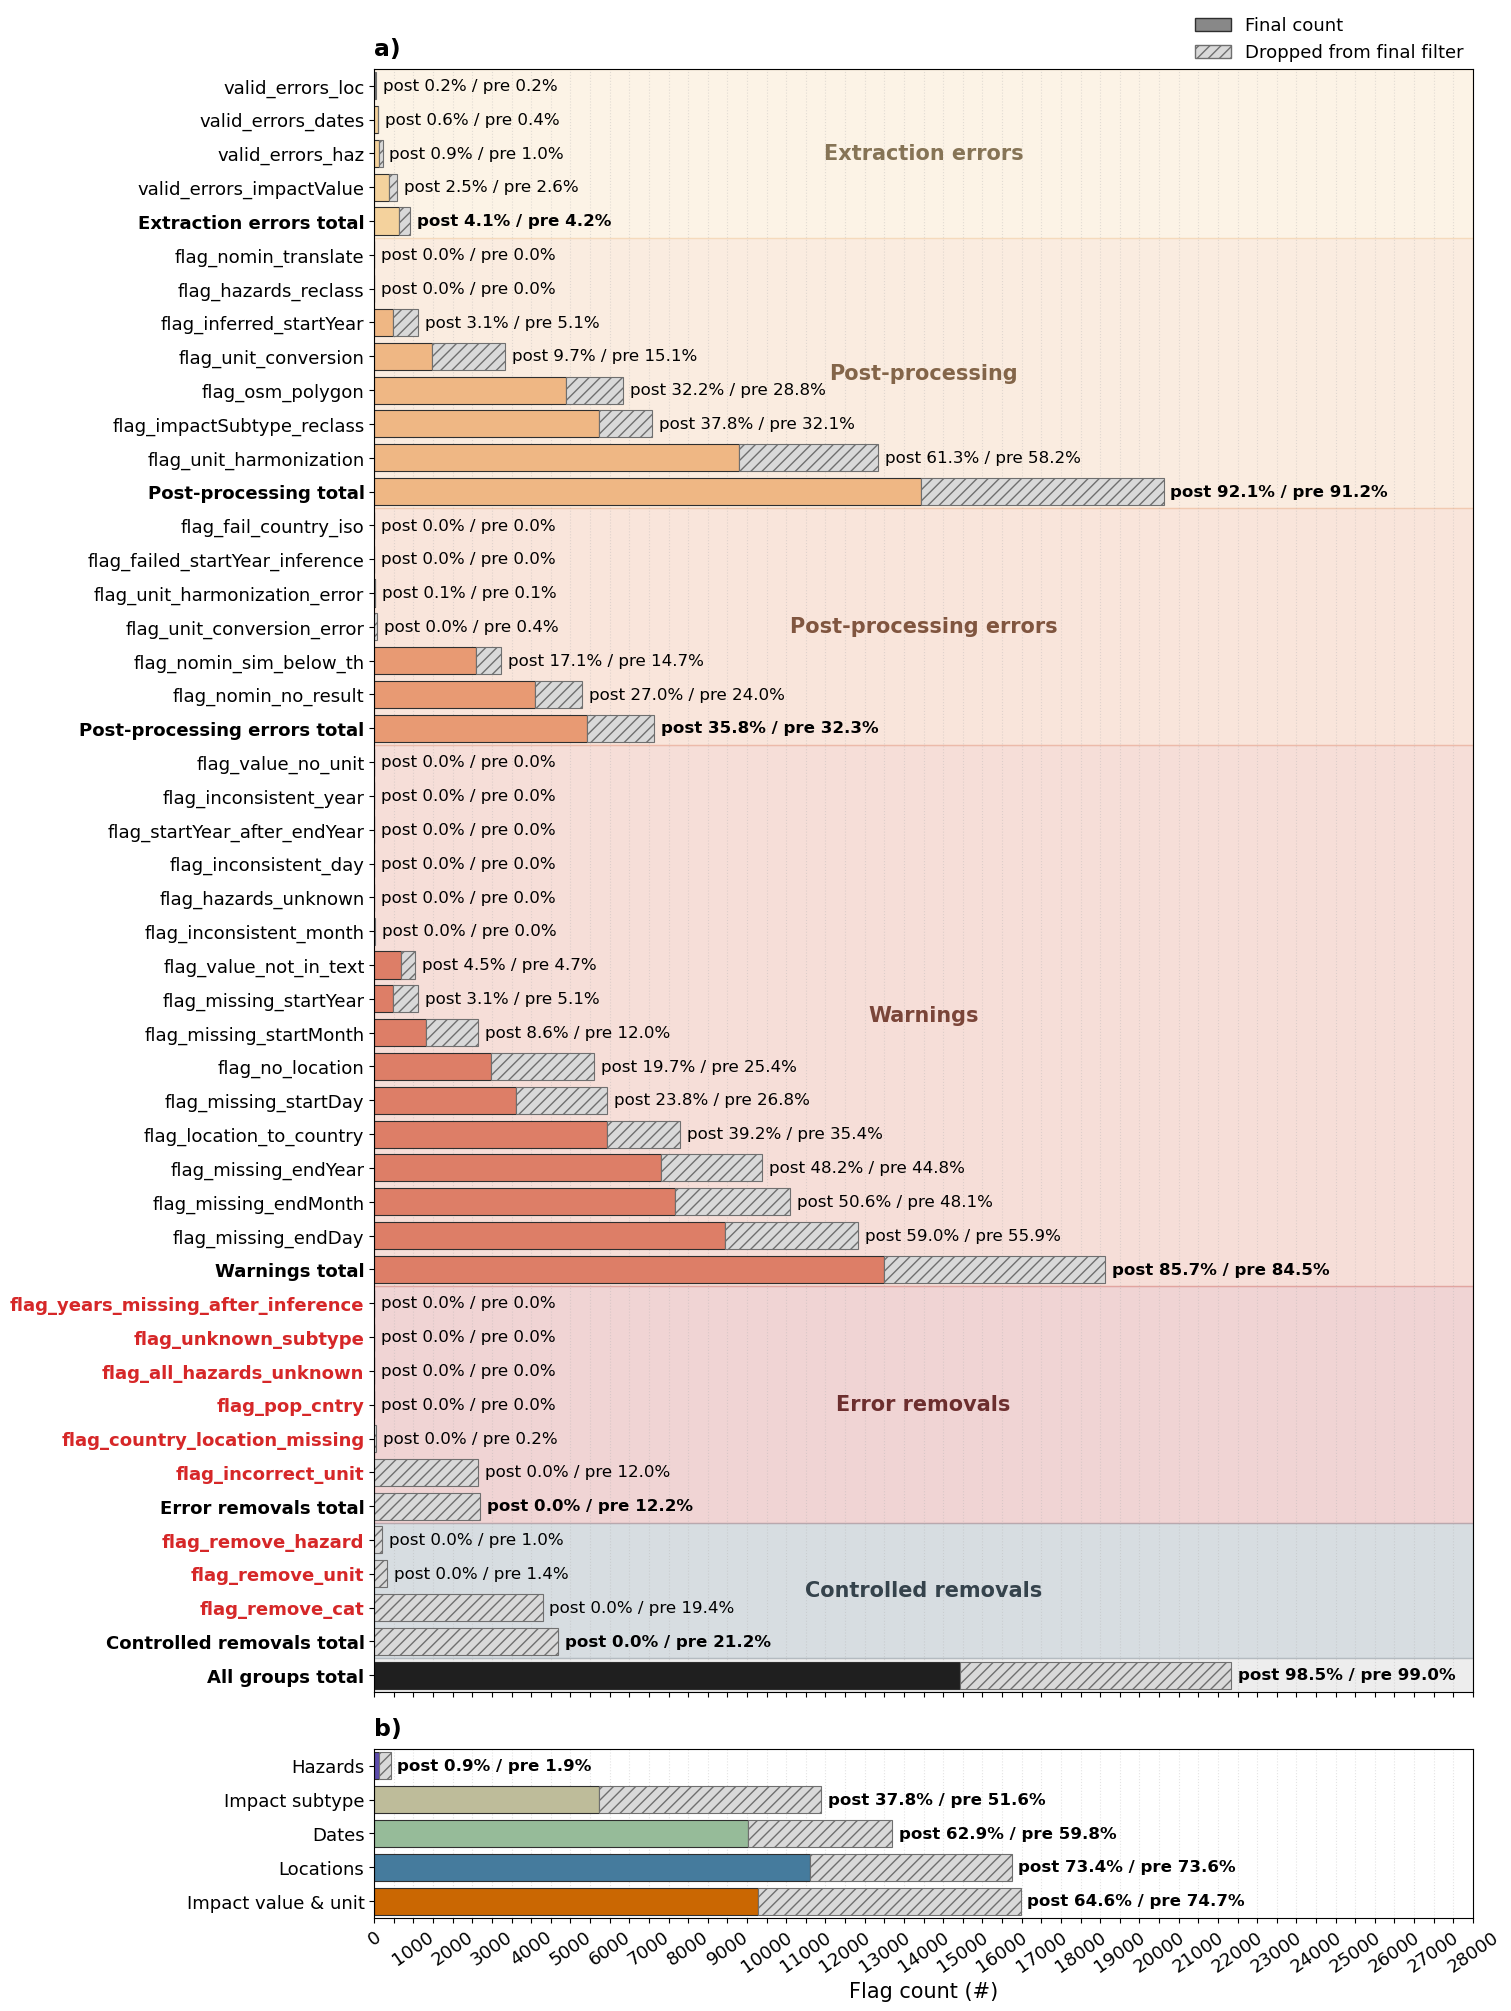

In [26]:
fig

In [29]:
plot_df

,label,category,row_type,pre_count,post_count,color,kept_count,dropped_count,added_count,pre_count_perc,post_count_perc
0,valid_errors_loc,Extraction errors,flag,39,29,#F4D29D,29,10,0,0.176799,0.191457
1,valid_errors_dates,Extraction errors,flag,95,89,#F4D29D,89,6,0,0.430663,0.587575
2,valid_errors_haz,Extraction errors,flag,211,131,#F4D29D,131,80,0,0.956526,0.864858
3,valid_errors_impactValue,Extraction errors,flag,582,381,#F4D29D,381,201,0,2.638379,2.515350
4,Extraction errors total,Extraction errors,category_total,917,623,#F4D29D,623,294,0,4.157033,4.113026
5,flag_nomin_translate,Post-processing,flag,0,0,#EFB784,0,0,0,0.000000,0.000000
6,flag_hazards_reclass,Post-processing,flag,3,0,#EFB784,0,3,0,0.013600,0.000000
7,flag_inferred_startYear,Post-processing,flag,1122,474,#EFB784,474,648,0,5.086359,3.129333
8,flag_unit_conversion,Post-processing,flag,3335,1463,#EFB784,1463,1872,0,15.118546,9.658678
9,flag_osm_polygon,Post-processing,flag,6351,4878,#EFB784,4878,1473,0,28.790970,32.204397


In [27]:
path_save_fig

WindowsPath('d:/data/ROUGE/figure/error_propagation')